# População por Sexo
Fonte de dados: https://censo2022.ibge.gov.br/panorama/?utm_source=ibge&utm_medium=home&utm_campaign=portal

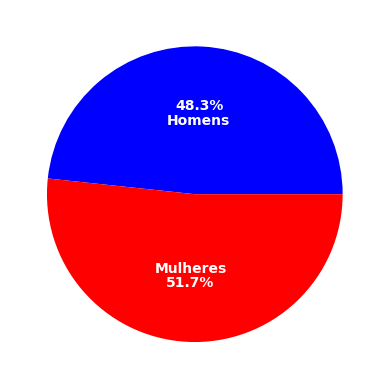

In [ ]:
# Valores
h = 7098
m = 7597

import pandas as pd
import matplotlib.pyplot as plt

def plot_pie_chart(values, labels, colors, filename=None):
    # Plotando o gráfico de pizza
    patches, texts, autotexts = plt.pie(values, labels=labels, colors=colors, autopct='%1.1f%%', textprops={'color': 'white', 'weight': 'bold'}, labeldistance=0.5)

    # Ajustando as cores das porcentagens
    for autotext in autotexts:
        autotext.set_color('white')  # Cor das porcentagens

    # Ajustando a posição dos labels
    for text in texts:
        text.set_horizontalalignment('center')  # Centralizar horizontalmente

    # Salvando a figura se um nome de arquivo for fornecido
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')

    plt.show()

# Rótulos
labels = ['Homens', 'Mulheres']

# Valores para os segmentos
pop = [h, m]

# Cores para os segmentos
colors = ['blue', 'red']

# Gerando o gráfico de pizza
plot_pie_chart(pop, labels, colors, (os.path.join(repopath,'população_por_sexo.png')))

# Pirâmide etária
Fonte de dados: https://censo2022.ibge.gov.br/panorama/?utm_source=ibge&utm_medium=home&utm_campaign=portal

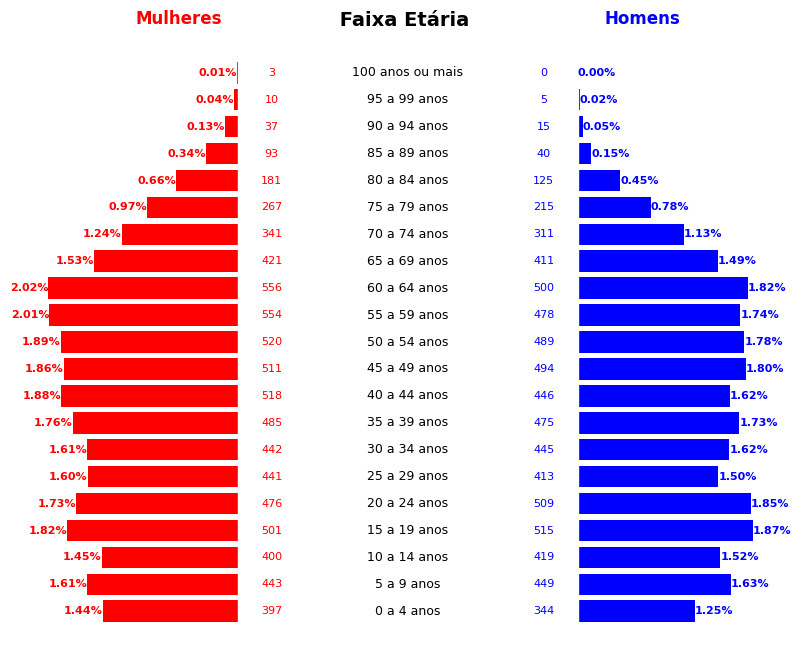

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


caminho_csv = rf'C:\Users\gabriel.coimbra\Desktop\Meus arquivos\Tapes\gráficos_t1_py\piramide_tapes.csv' #caminho do documento XXX do panorama
pop = 27498 #população municipal último censo

def plot_piramide_etaria(dataframe, save_path=None):
    # Calculando as porcentagens
    dataframe['Porcentagem M'] = dataframe['População masculina(pessoas)'] / pop
    dataframe['Porcentagem F'] = dataframe['População feminina(pessoas)'] / pop

    # Invertendo a ordem dos dados
    dataframe = dataframe.iloc[::-1]

    # Plotando a pirâmide etária
    plt.figure(figsize=(10, 8))
    bars_m = plt.barh(dataframe['Grupo de idade'], dataframe['População masculina(pessoas)'] + 500, color='blue', label='Masculino')
    bars_f = plt.barh(dataframe['Grupo de idade'], -(dataframe['População feminina(pessoas)'] + 500), color='red', label='Feminino')

    # Adicionando os labels nas barras
    plt.bar_label(bars_m, labels=[f'{p * 100:.2f}%' for p in dataframe['Porcentagem M']], label_type='edge', color='blue', fontsize=8, fontweight='bold')
    plt.bar_label(bars_f, labels=[f'{p * 100:.2f}%' for p in dataframe['Porcentagem F']], label_type='edge', color='red', fontsize=8, fontweight='bold')

    # Adicionando os rótulos do eixo y no meio
    for i, label in enumerate(dataframe['Grupo de idade']):
        plt.text(0, i, label, ha='center', va='center', color='black', fontsize=9)

    # Adicionando os textos "Homens" e "Mulheres" na parte superior esquerda e direita, respectivamente
    plt.text(800, len(dataframe) + 1, 'Homens', ha='right', va='center', color='blue', fontsize=12, fontweight='bold')
    plt.text(-800, len(dataframe) + 1, 'Mulheres', ha='left', va='center', color='red', fontsize=12, fontweight='bold')

    # Adicionando a população por faixa etária acima do axvspan
    for index, row in dataframe.iterrows():
        plt.text(400, len(dataframe) - index - 1, f"{row['População masculina(pessoas)']}", ha='center', va='center', color='blue', fontsize=8)
        plt.text(-400, len(dataframe) - index - 1, f"{row['População feminina(pessoas)']}", ha='center', va='center', color='red', fontsize=8)

    plt.box(False)
    plt.axis('off')

    # Definindo título do gráfico
    plt.title(' Faixa Etária', fontweight='bold', fontsize=14)

    # Adicionando retângulo branco para criar espaço em branco
    plt.axvspan(-500, 500, color='white')
    
    # Salvando o gráfico se o caminho de salvamento for fornecido
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

# Carregando o arquivo CSV
df = pd.read_csv(caminho_csv, delimiter=';')

# Chamando a função para plotar a pirâmide etária
plot_piramide_etaria(df, save_path=(os.path.join(repopath,'piramide_etaria.png')))